### Импорты библиотек и константы

In [65]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split, cross_validate, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import optuna

import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

In [22]:
RANDOM_STATE = 42
%matplotlib inline
warnings.filterwarnings("ignore")

In [23]:
df = pd.read_csv('../../data/preprocessed.csv')
df.sample(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
162070,529,France,Male,27,7,0.00,2,1,0,184221.11,0
41704,684,France,Male,33,9,191523.09,1,1,1,167058.75,0
90995,435,Spain,Male,37,8,114346.30,1,1,0,980.93,0
122102,632,Germany,Female,34,9,130499.29,1,0,1,194998.34,0
111012,651,Germany,Male,43,5,134593.23,2,1,1,143635.56,0


### 1. Линейные модели классификации

#### 1.1 Кодирование категориальных признаков

к колонкам `Gender`, `Geography` с малым количеством категорий применим в пайплайне One-Hot-Encoding

In [24]:
print(df['Gender'].value_counts())
print(df['Geography'].value_counts())

X, y = df.drop(columns='Exited'), df['Exited']
print(X.describe())

num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Tenure']
ohe_features = ['Gender', 'Geography']
ohe = OneHotEncoder(drop='first', handle_unknown='ignore')

Gender
Male      93150
Female    71884
Name: count, dtype: int64
Geography
France     94215
Spain      36213
Germany    34606
Name: count, dtype: int64
         CreditScore            Age         Tenure        Balance  \
count  165034.000000  165034.000000  165034.000000  165034.000000   
mean      656.454373      38.125883       5.020353   55478.086689   
std        80.103340       8.867207       2.806159   62817.663278   
min       350.000000      18.000000       0.000000       0.000000   
25%       597.000000      32.000000       3.000000       0.000000   
50%       659.000000      37.000000       5.000000       0.000000   
75%       710.000000      42.000000       7.000000  119939.517500   
max       850.000000      92.000000      10.000000  250898.090000   

       NumOfProducts      HasCrCard  IsActiveMember  EstimatedSalary  
count  165034.000000  165034.000000   165034.000000    165034.000000  
mean        1.554455       0.753954        0.497770    112574.822734  
std         0

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ('categ', ohe, ohe_features),
        ('num', StandardScaler(), num_cols)
    ], remainder='passthrough'
)

#### 1.2 Пайплайн обучения модели с учетом дисбаланса классов

In [26]:
print(f"Баланс классов: {y.value_counts(normalize=True)}")
# для честной оценки модели: не устраняет дисбаланс, а сохраняет его пропорцию в каждом фолде
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000,
                               random_state=RANDOM_STATE,
                               class_weight='balanced'  # автоматически взвешивать классы
                               ))
])

Баланс классов: Exited
0    0.788401
1    0.211599
Name: proportion, dtype: float64


#### 1.3 Выбор метрики качества моделей

Accuracy (доля верных ответов) - очень плохой выбор для оценки моделей при дисбалансе классов. 
Рассмотрим другие метрики. Будем учитывать, что в нашей бизнес-задаче важнее не допустить оттока клиентов (class 1 - доля в таргете 21%).

* Precision (точность) - какая доля из помеченных уходящими действительно уйдёт. Второстепенная метрика 
* Recall (полнота) - какую долю модель выявила из реально уходящих. Важная метрика
* F-1 мера - усредненная метрика по точности и полноте. Подходит для несбалансированных данных
* ROC-AUC - интегральная метрика, не требует подбора порога для каждой модели. Хороша для подбора модели
* PR-AUC - также интегральная метрика. При сильном дисбалансе более информативна, показывает, насколько хорошо модель находит редкий класс

##### Итоги: 
При подборе гиперпараметров в `GridSearch` будем использовать `recall`, но видеть и PR-AUC(scoring=`average_precision`). В classification_report обращаем внимание на 1 класс.

Функция для визуализации оценки качества моделей

In [27]:
def print_metrics(y_true, y_pred, y_proba,
                  cv_metrics=None,
                  pipeline_name="Logistic Regression",
                  figsize=(8, 8), cmap="Blues"):
    """
    Выводит в консоль метрики по кросс-валидации на трейне. 
    Выводит Classification Report на тесте.
    Строит и показывает матрицу ошибок."""

    if cv_metrics is not None:
        print("CV-метрики на train (среднее):")
        for k, v in cv_metrics.items():
            if k.startswith('test_'):
                print(f"{k.replace('test_', '')}: {v.mean():.4f}")

    print("\nClassification Report на test:")
    print(classification_report(y_true, y_pred))
    print(f"PR-AUC (test): {average_precision_score(y_true, y_proba):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap)
    plt.title(f"Confusion matrix {pipeline_name}")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

CV-метрики на train (среднее):
recall: 0.7379
average_precision: 0.5827

Classification Report на test:
              precision    recall  f1-score   support

           0       0.91      0.76      0.83     32529
           1       0.45      0.73      0.56      8730

    accuracy                           0.75     41259
   macro avg       0.68      0.75      0.69     41259
weighted avg       0.82      0.75      0.77     41259

PR-AUC (test): 0.5706


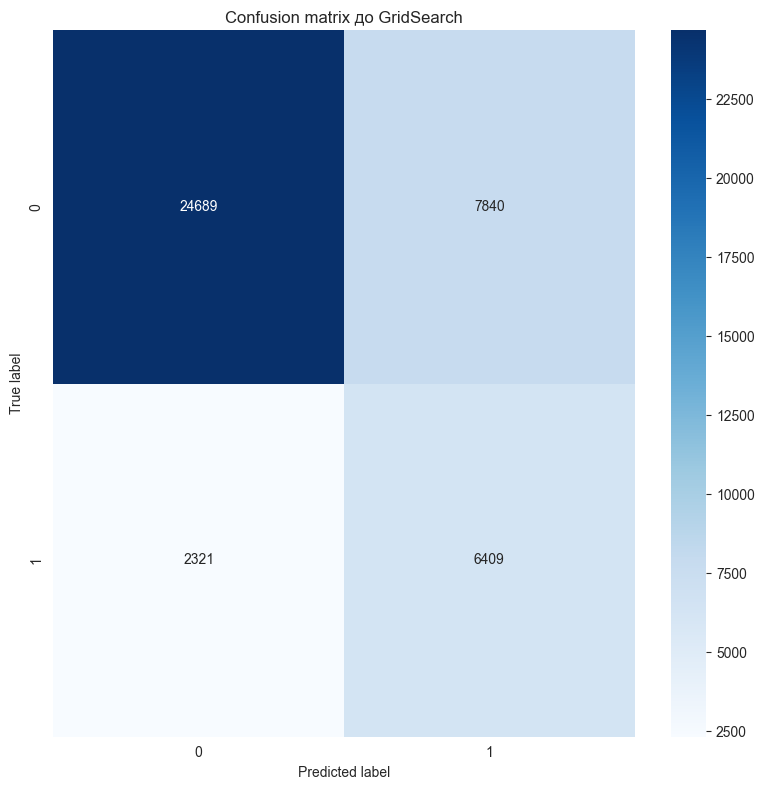

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE, stratify=y)
pipeline.fit(X_train, y_train)

cv_metrics = cross_validate(
    pipeline, X_train, y_train, cv=skf,
    scoring=['recall', 'average_precision'],
    return_train_score=False, n_jobs=-1
)
# Финальная оценка на тесте
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]
print_metrics(y_test, y_pred, y_proba, cv_metrics, "до GridSearch")

Видим на модели LogisticRegression с параметрами по умолчанию и взвешенными классами:
recall 1 класса ~ 0.73 

precision 1 класса ~ 0.45

PR_AUC ~ 0.57

FN 2321 Модель пропускает  (~27%) уходящих клиентов

#### 1.4 Подбор гиперпараметров модели логистической регрессии

In [29]:
param_grid = {
    'clf__C': np.logspace(-1, 1, 7),
    'clf__class_weight': ['balanced', None, {0: 1, 1: 4}],
    'clf__l1_ratio': np.linspace(0.0, 1.0, 7)
}
grid = GridSearchCV(pipeline,
                    param_grid,
                    cv=skf,
                    scoring={
                        'pr_auc': 'average_precision',
                        'recall': 'recall'  # Recall (по порогу 0.5)
                    },
                    refit='recall',
                    n_jobs=-1,
                    return_train_score=True,
                    )
start = time.perf_counter()  # perf_counter точнее для замеров длительности
grid.fit(X_train, y_train)
end = time.perf_counter()
total_duration_logreg_base = end - start
print(f"Общее время работы GridSearchCV: {total_duration_logreg_base:.2f} сек")

best_model = grid.best_estimator_
print(grid.best_params_)

Общее время работы GridSearchCV: 20.83 сек
{'clf__C': np.float64(0.1), 'clf__class_weight': {0: 1, 1: 4}, 'clf__l1_ratio': np.float64(0.0)}


Видим, что GridSearch подобрал:

l1_ratio=0 отбросил L1-компонент => достаточно penalty='l2' с дефолтным solver='lbfgs'

С= 0.1 самая сильная регуляризация из набора

class_weight: {0: 1, 1: 4} подтверждает исходную перекошенность таргета



CV-метрики на train (среднее):
precision: 0.4383
recall: 0.7536
average_precision: 0.5820

Classification Report на test:
              precision    recall  f1-score   support

           0       0.92      0.74      0.82     32529
           1       0.44      0.75      0.55      8730

    accuracy                           0.74     41259
   macro avg       0.68      0.74      0.69     41259
weighted avg       0.81      0.74      0.76     41259

PR-AUC (test): 0.5699


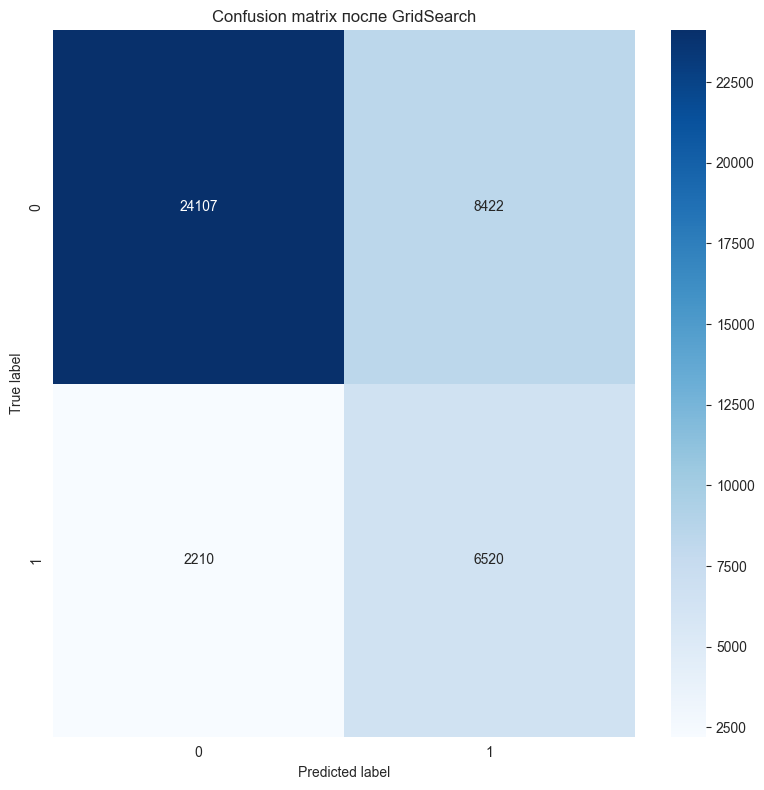

In [30]:
cv_metrics_opt = cross_validate(
    best_model, X_train, y_train, cv=skf,
    scoring=['precision', 'recall', 'average_precision'],
    return_train_score=False, n_jobs=-1
)
y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:, 1]
print_metrics(y_test, y_pred_opt, y_proba_opt, cv_metrics_opt, "после GridSearch")

#### Вывод: 

Из модели LogisticRegression c сильной регуляризацией и взвешенными штрафами для несбалансированных классов удалось "выжать" следующие метрики: 

Recall 1 класса ~ 0.75

PR_AUC ~ 0.57

FN=2210 Модель пропускает 25% уходящих клиентов. 
Возьмем эту модель в качестве `Baseline`

In [31]:
model_artifact = {
    "model": best_model,
    "best_params": grid.best_params_,
    "feature_names": X_train.columns.tolist(),  # критично для совпадения колонок
    "metrics": {
        "cv_recall": grid.best_score_,
        "test_pr_auc": average_precision_score(y_test, y_proba_opt)
    }
}

joblib.dump(model_artifact, "churn_model_artifact.pkl", compress=3)

['churn_model_artifact.pkl']

#### 1.5 Подбор оптимального порога

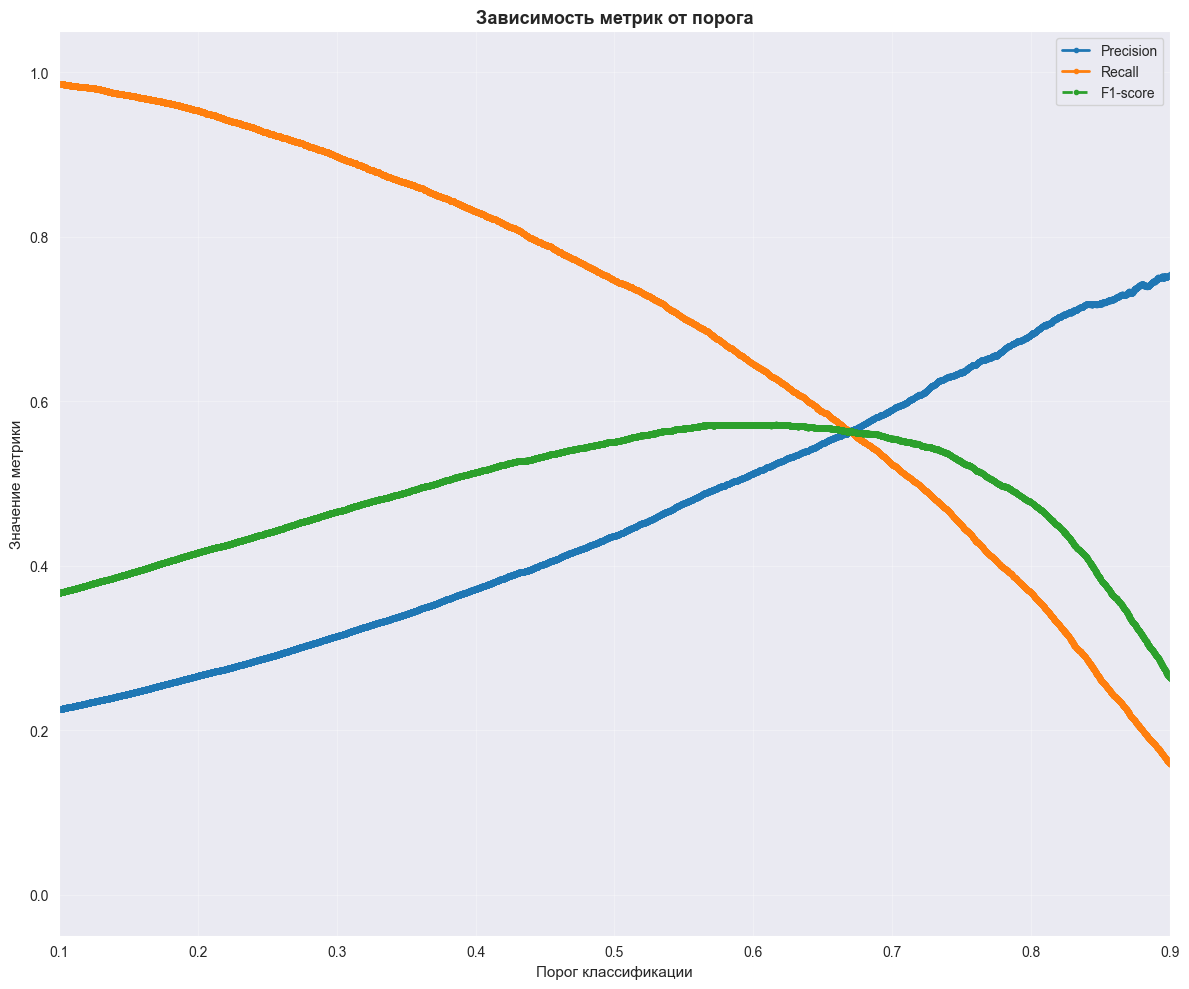

In [32]:
def plot_metrics_vs_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

    plt.figure(figsize=(12, 10))
    plt.plot(thresholds, precisions[:-1], label='Precision', marker='.', linewidth=2)
    plt.plot(thresholds, recalls[:-1], label='Recall', marker='.', linewidth=2)
    plt.plot(thresholds, f1_scores, label='F1-score', marker='.', linewidth=2, linestyle='--')

    plt.xlabel('Порог классификации', fontsize=11)
    plt.ylabel('Значение метрики', fontsize=11)
    plt.title('Зависимость метрик от порога', fontsize=13, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xlim([0.1, 0.9])
    plt.tight_layout()
    plt.show()


plot_metrics_vs_threshold(y_test, y_proba_opt)

Применим кастомный порог классификации, чтобы увеличить полноту до ~0.80


Classification Report на test:
              precision    recall  f1-score   support

           0       0.93      0.62      0.75     32529
           1       0.37      0.83      0.51      8730

    accuracy                           0.67     41259
   macro avg       0.65      0.73      0.63     41259
weighted avg       0.81      0.67      0.70     41259

PR-AUC (test): 0.5699


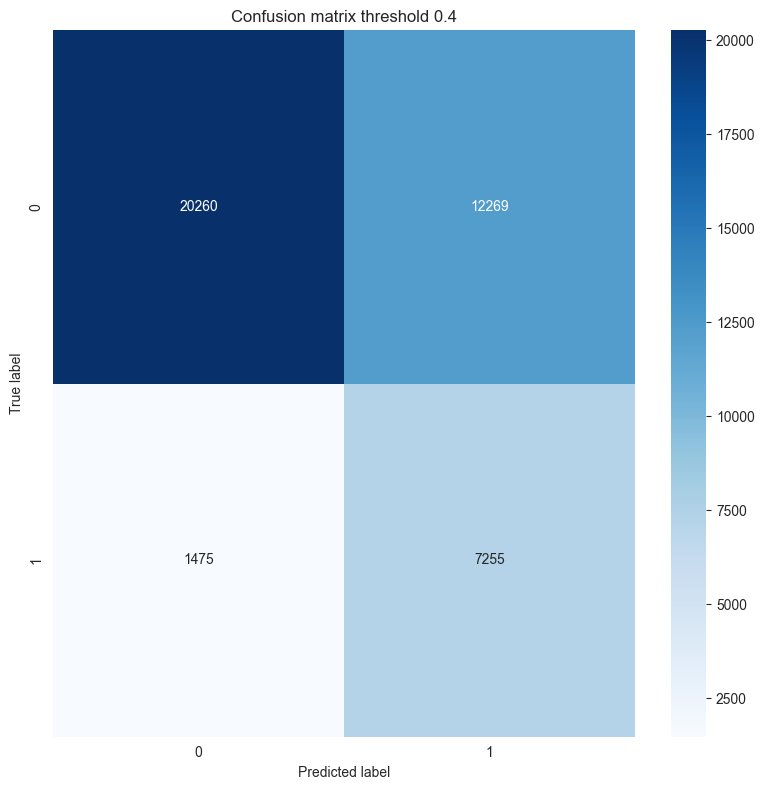

In [33]:
threshold = 0.4
y_pred_custom = (y_proba_opt >= threshold)
print_metrics(y_test, y_pred_custom, y_proba_opt, pipeline_name=f"threshold {threshold}")


Видим:  
recall 1 класса ~ 0.83   Полнота увеличилась на 8 п.п.

precision 1 класса ~ 0.37 Точность соответственно упала на 7 п.п.

FN 1475 Модель пропускает значительно меньше (~17%) уходящих клиентов. 


#### Вывод: 

Снижение порога классификации эффективно для повышения метрики полноты интересующего нас класса. 
Хотя FP (ложно-уходящие) велик (38% лояльных клиентов), но предотвратить отток клиентов важнее. 

#### 1.6 Feature Engineering для логистической регрессии

#### PolynomialFeatures

Новые лучшие параметры: {'clf__C': 0.1, 'clf__class_weight': {0: 1, 1: 4}, 'clf__l1_ratio': 0.0}

Classification Report на test:
              precision    recall  f1-score   support

           0       0.92      0.74      0.82     32529
           1       0.44      0.75      0.55      8730

    accuracy                           0.74     41259
   macro avg       0.68      0.74      0.68     41259
weighted avg       0.81      0.74      0.76     41259

PR-AUC (test): 0.5691


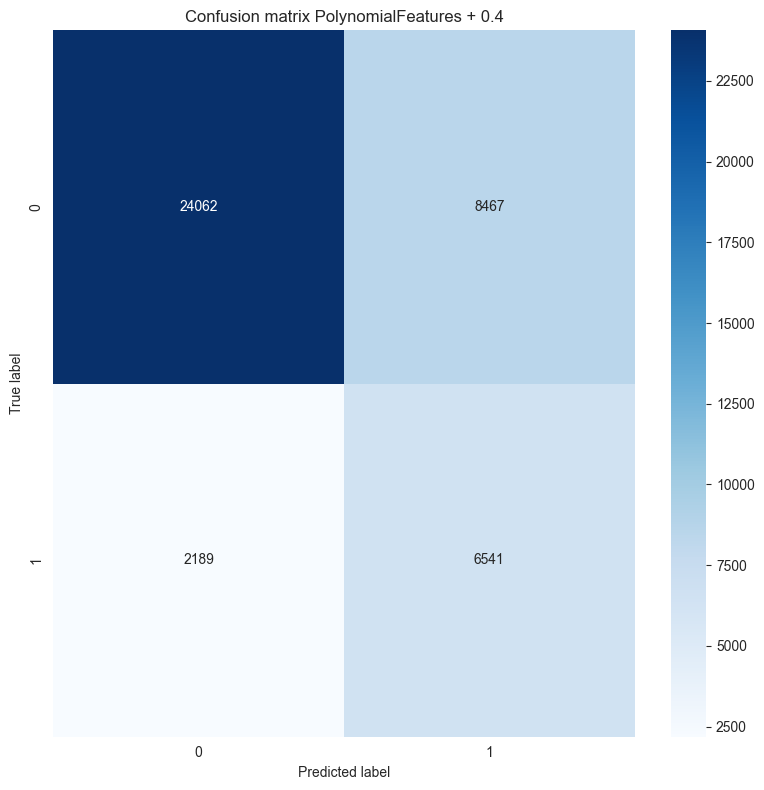

In [34]:
preprocessor = ColumnTransformer([
    ('poly', Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False))
    ]), num_cols),
    ('categ', ohe, ohe_features),
], remainder='passthrough')

param_grid_pf = {
    'clf__C': [0.1, 0.5, 1.0, 5.0],  # принудительно убираем 0.01  
    'clf__l1_ratio': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0],  # добавили чистый Ridge (0.0)
    'clf__class_weight': ['balanced', {0: 1, 1: 4}]
}

pf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        penalty='elasticnet',  # ← ОБЯЗАТЕЛЬНО для работы l1_ratio
        solver='saga',
        max_iter=5000,
        random_state=RANDOM_STATE))
])
grid_pf = GridSearchCV(
    pf_pipeline,
    param_grid=param_grid_pf,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    refit=True
)
grid_pf.fit(X_train, y_train)
print("Новые лучшие параметры:", grid_pf.best_params_)

y_proba_poly = grid_pf.predict_proba(X_test)[:, 1]
y_pred_poly = grid_pf.predict(X_test)

print_metrics(y_test, y_pred_poly, y_proba_poly, pipeline_name=f"PolynomialFeatures + {threshold}")

#### Выводы: 
После добавления PolynomialFeatures метрики всё ещё не растут


#### Сэмплирование - алгоритм SMOTE (Synthetic Minority Oversampling Techniques)

In [35]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline
from collections import Counter

preprocessor = ColumnTransformer(
    transformers=[
        ('categ', ohe, ohe_features),
        ('num', StandardScaler(), num_cols)
    ], remainder='passthrough'
)

pipeline_smote = make_pipeline(
    preprocessor,
    SMOTE(random_state=RANDOM_STATE, k_neighbors=5),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)
pipeline_smote.fit(X_train, y_train)

print("Баланс классов до семплирования:", Counter(y_train))

X_train_num = preprocessor.transform(X_train)
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X_train_num, y_train)

print("Баланс классов после SMOTE:", Counter(y_resampled))

Баланс классов до семплирования: Counter({0: 97584, 1: 26191})
Баланс классов после SMOTE: Counter({1: 97584, 0: 97584})



Classification Report на test:
              precision    recall  f1-score   support

           0       0.91      0.76      0.83     32529
           1       0.45      0.73      0.56      8730

    accuracy                           0.76     41259
   macro avg       0.68      0.75      0.69     41259
weighted avg       0.82      0.76      0.77     41259

PR-AUC (test): 0.5733


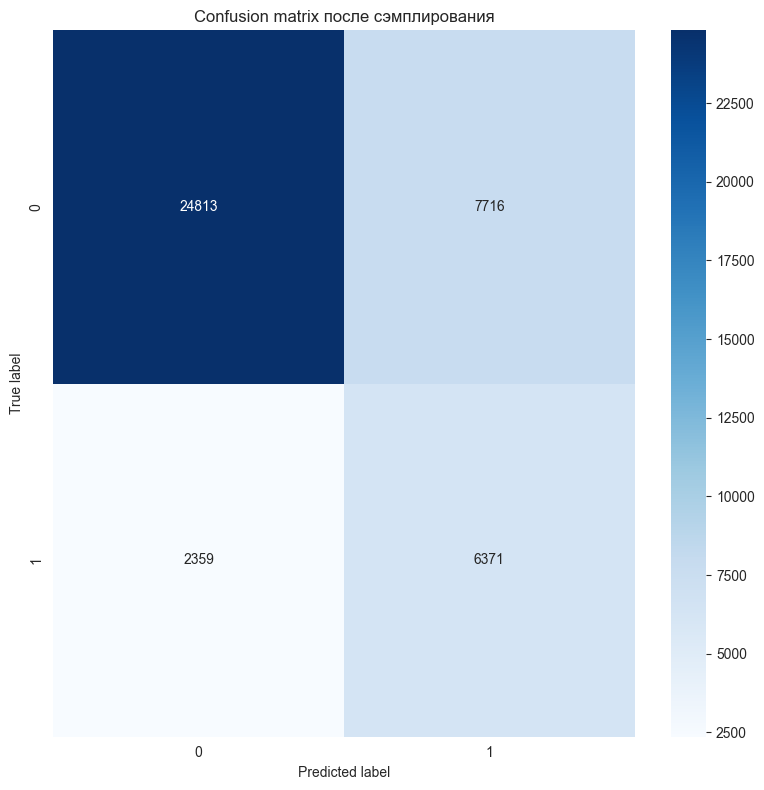

In [36]:
y_proba_sm = pipeline_smote.predict_proba(X_test)[:, 1]
y_pred_sm = pipeline_smote.predict(X_test)
print_metrics(y_test, y_pred_sm, y_proba_sm, pipeline_name="после сэмплирования")

Результаты хуже, чем у Baseline

#### Выводы: 
Простые способы Feature Engineering не принесли свои плоды. Переходим к нелинейным моделям

### 2. Решающие деревья

#### 2.1 Базовая модель + GridSearchCV

In [69]:
dtc = DecisionTreeClassifier(random_state=RANDOM_STATE)
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

tree_preproc = ColumnTransformer(transformers=[
    ('categ', ohe, ohe_features)
], remainder='passthrough',
    verbose_feature_names_out=False
)
pipeline = Pipeline([
    ('preprocessor', tree_preproc),
    ('clf', dtc)])
param_grid = {
    'clf__max_depth': range(2, 9),
    'clf__min_samples_split': [2, 5, 10, 15],
    'clf__min_samples_leaf': range(1, 11),
    'clf__max_features': ['sqrt', 'log2'],
    'clf__class_weight': ['balanced', {0: 1, 1: 4}],
}
gs = GridSearchCV(pipeline,
                  param_grid=param_grid,
                  cv=skf,
                  scoring='recall',
                  n_jobs=-1,
                  refit=True)
start = time.perf_counter()  # perf_counter точнее для замеров длительности
gs.fit(X_train, y_train)
end = time.perf_counter()
total_duration_gs = end - start
print(f"Общее время работы GridSearchCV: {total_duration_gs:.2f} сек")

print(f'Лучшие параметры: {gs.best_params_}')
print(f'Лучшее качество на кросс-валидации: {gs.best_score_:.4f}')

Общее время работы GridSearchCV: 100.96 сек
Лучшие параметры: {'clf__class_weight': 'balanced', 'clf__max_depth': 3, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
Лучшее качество на кросс-валидации: 0.9172


CV-метрики на train (среднее):
precision: 0.2849
recall: 0.9172
average_precision: 0.3487

Classification Report на test:
              precision    recall  f1-score   support

           0       0.94      0.38      0.55     32529
           1       0.28      0.91      0.43      8730

    accuracy                           0.50     41259
   macro avg       0.61      0.65      0.49     41259
weighted avg       0.80      0.50      0.52     41259

PR-AUC (test): 0.3573


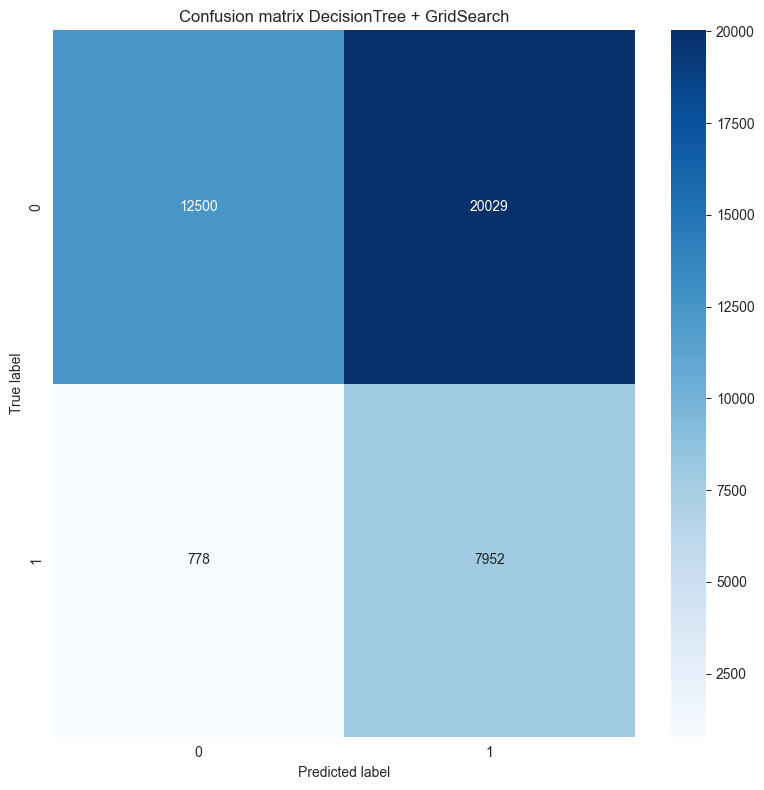

In [58]:
cv_metrics_dt_gs = cross_validate(
    gs.best_estimator_, X_train, y_train, cv=skf,
    scoring=['precision', 'recall', 'average_precision'],
    return_train_score=False, n_jobs=-1
)
y_pred_dt_gs = gs.predict(X_test)
y_proba_dt_gs = gs.predict_proba(X_test)[:, 1]
print_metrics(y_test, y_pred_dt_gs, y_proba_dt_gs, cv_metrics_dt_gs, "DecisionTree + GridSearch")

Видим метрики на тестовой выборке

recall 1 класса 0.91 выше на 16 п.п., чем у Baseline 

PR-AUC ~0.36 существенно ниже

FN=778 Модель пропускает ~9% уходящих клиентов

#### 2.2 Улучшение. Optuna подбор гиперпараметров

In [59]:
def objective(trial):
    max_depth = trial.suggest_int('max_depth', 2, 12)
    min_samples_split = trial.suggest_int('min_samples_split', 3, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 15)
    max_features = trial.suggest_categorical('max_features', [None, 'sqrt', 'log2'])
    class_weight = trial.suggest_categorical('class_weight', ['balanced', {0: 1, 1: 3}, {0: 1, 1: 4}])

    model = DecisionTreeClassifier(random_state=RANDOM_STATE,
                                   max_depth=max_depth,
                                   min_samples_split=min_samples_split,
                                   min_samples_leaf=min_samples_leaf,
                                   max_features=max_features,
                                   class_weight=class_weight)
    pipeline = Pipeline([
        ('preprocessor', tree_preproc),
        ('clf', model)
    ])
    recall = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring="recall", n_jobs=1).mean()
    return recall

In [71]:
study = optuna.create_study(direction='maximize', study_name="DecisionTree")

start = time.perf_counter()
study.optimize(objective, n_trials=100, timeout=50, show_progress_bar=True)
total_duration_dt_op = time.perf_counter() - start

[I 2026-04-21 11:38:12,142] A new study created in memory with name: DecisionTree


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-21 11:38:12,450] Trial 0 finished with value: 0.917223461687069 and parameters: {'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 13, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.917223461687069.
[I 2026-04-21 11:38:13,223] Trial 1 finished with value: 0.7399875508971873 and parameters: {'max_depth': 6, 'min_samples_split': 18, 'min_samples_leaf': 15, 'max_features': None, 'class_weight': {0: 1, 1: 3}}. Best is trial 0 with value: 0.917223461687069.
[I 2026-04-21 11:38:14,262] Trial 2 finished with value: 0.7306328732078624 and parameters: {'max_depth': 11, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': None, 'class_weight': {0: 1, 1: 3}}. Best is trial 0 with value: 0.917223461687069.
[I 2026-04-21 11:38:15,158] Trial 3 finished with value: 0.7773280013536816 and parameters: {'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 12, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 0 with

In [72]:
print(f"\nОбщее время работы Optuna: {total_duration_dt_op:.2f} сек")
print(f'Лучшие параметры: {study.best_params}')
print(f"CV-метрика Recall на train (среднее): {study.best_value:.4f}")


Общее время работы Optuna: 34.48 сек
Лучшие параметры: {'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 13, 'max_features': 'log2', 'class_weight': 'balanced'}
CV-метрика Recall на train (среднее): 0.9172



Classification Report на test:
              precision    recall  f1-score   support

           0       0.94      0.38      0.55     32529
           1       0.28      0.91      0.43      8730

    accuracy                           0.50     41259
   macro avg       0.61      0.65      0.49     41259
weighted avg       0.80      0.50      0.52     41259

PR-AUC (test): 0.3573


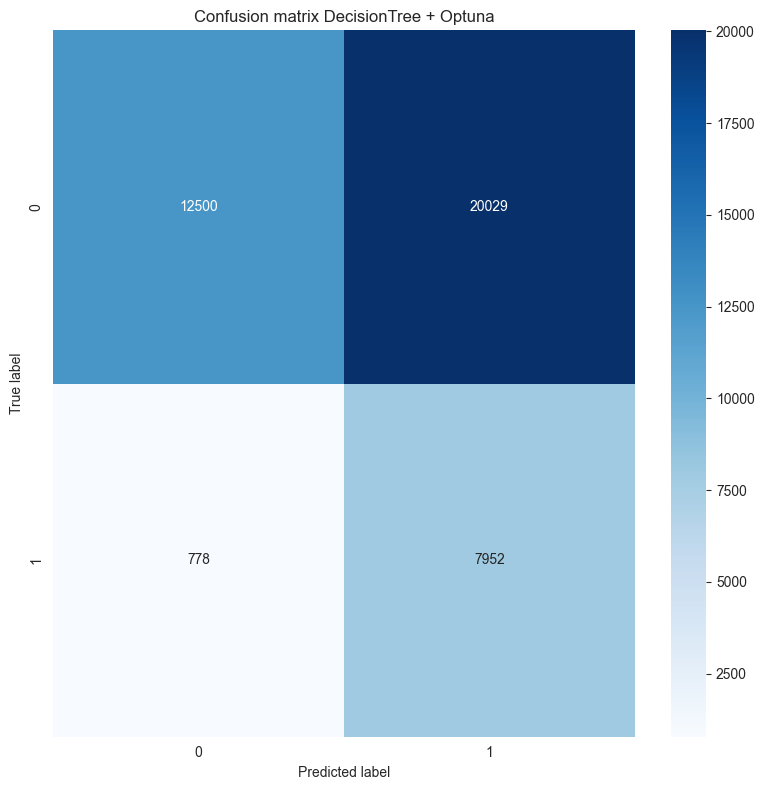

In [73]:
pipeline = Pipeline([
    ('preprocessor', tree_preproc),
    ('clf', DecisionTreeClassifier(**study.best_params, random_state=RANDOM_STATE))
])
pipeline.fit(X_train, y_train)
pred_op = pipeline.predict(X_test)
proba_op = pipeline.predict_proba(X_test)[:, 1]
print_metrics(y_test, pred_op, proba_op, pipeline_name="DecisionTree + Optuna")

Видим, что метрики точно такие же. Но у Optuna большой выигрыш по времени и диапазону параметров

Посмотрим на наше прекрасное дерево)

#### 2.3 Визуализация дерева и важности признаков

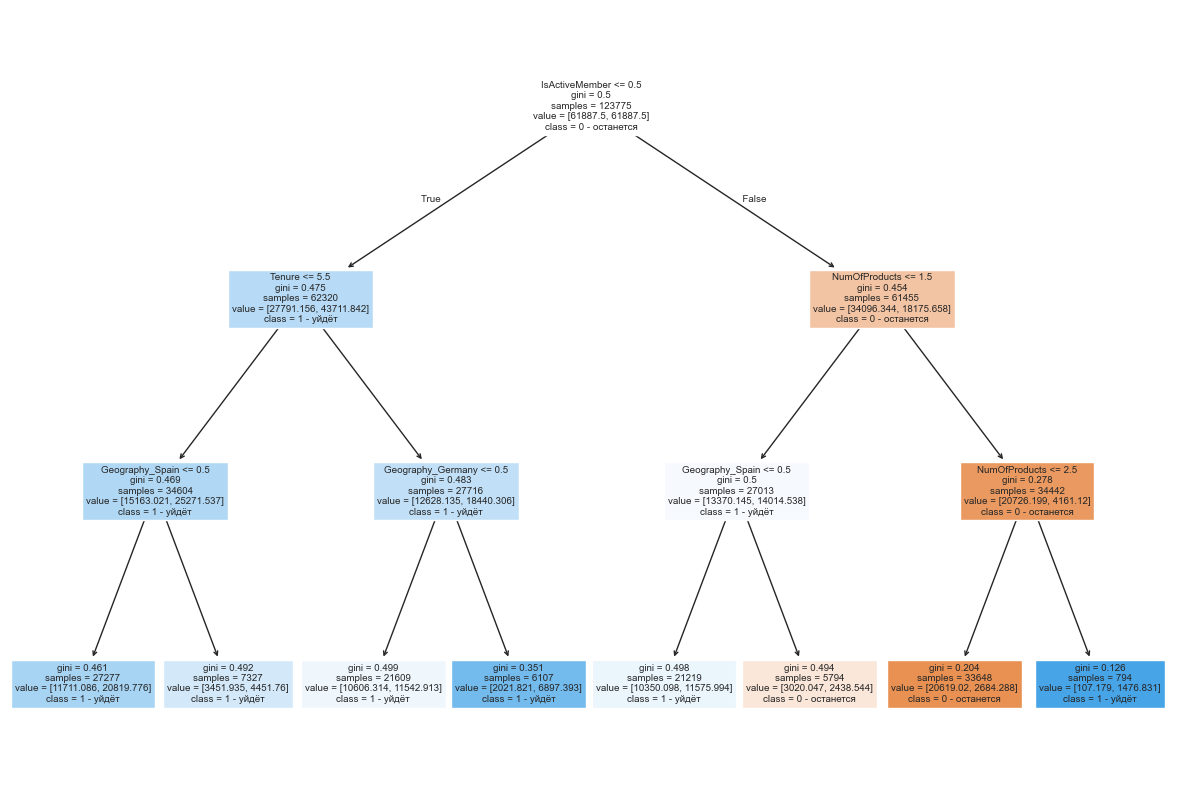

In [74]:
tree_optuna = pipeline.named_steps['clf']
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
plt.figure(figsize=(15, 10))
plot_tree(
    tree_optuna,
    feature_names=feature_names,
    class_names=["0 - останется", "1 - уйдёт"],
    filled=True,  # расцветка графа
)
plt.show()

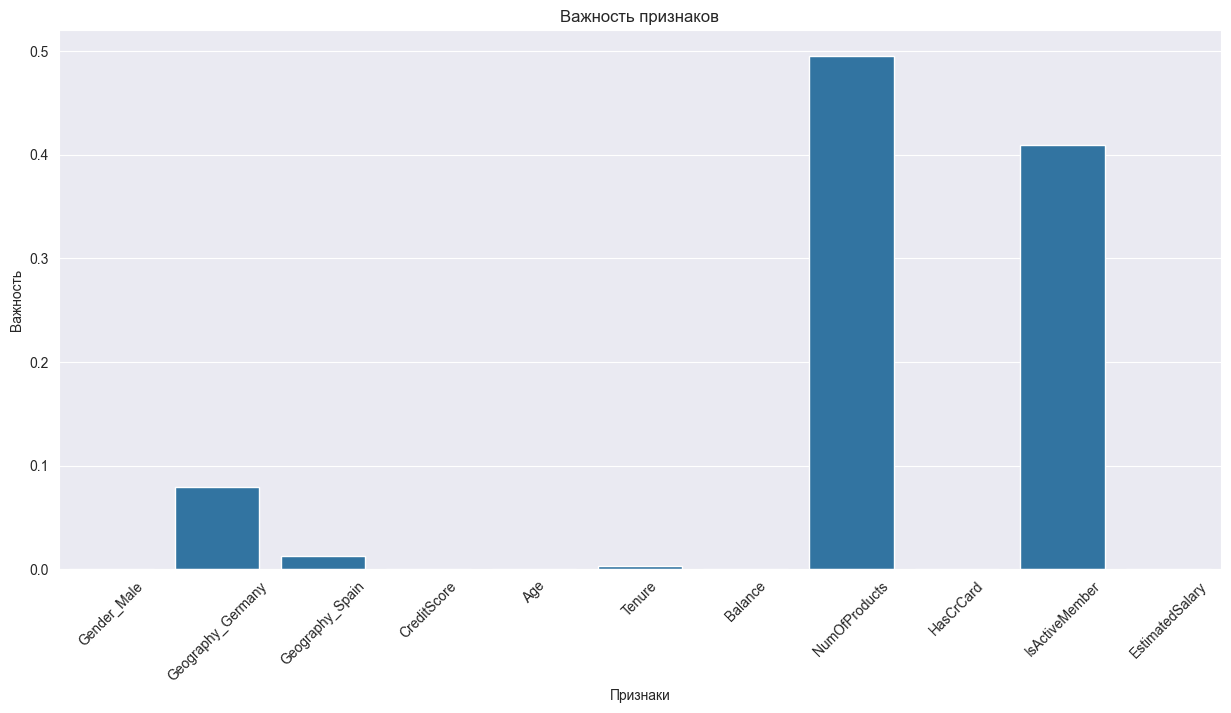

In [76]:
feature_importances = tree_optuna.feature_importances_
plt.figure(figsize=(15, 7))
# Строим столбчатую диаграмму
sns.barplot(x=feature_names, y=feature_importances)
plt.title('Важность признаков')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.xticks(rotation=45)
plt.show()

### 3. Случайный лес